# Fetal Health Classification: Decision Tree
## Objective
The objective of this project is to develop a multiclass model to classify CTG features into the three fetal health states, that is
**Normal**, **Suspect**, and **Pathological**, using features extracted from Cardiotocogram (CTG) examinations.

Cardiotocography is a widely used, non-invasive prenatal monitoring technique that records fetal heart rate and uterine contractions. Early identification of abnormal fetal conditions can help healthcare professionals take timely interventions, reducing the risk of maternal and neonatal complications.

This project evaluates and compares the performance of four classification algorithms:

- K-Nearest Neighbors (KNN)
- SVM Classifiers
- Decision Tree


Dataset taken from Kaggle, Citation:
Ayres de Campos et al. (2000) SisPorto 2.0 A Program for Automated Analysis of Cardiotocograms. J Matern Fetal Med 5:311-318

https://onlinelibrary.wiley.com/doi/10.1002/1520-6661(200009/10)9:5%3C311::AID-MFM12%3E3.0.CO;2-9

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
df=pd.read_csv("fetal_health.csv")
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [5]:
df["fetal_health"].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


In [6]:
# Features and Target
# removing target class from dataset

X = df.drop("fetal_health", axis=1)
y = df["fetal_health"].astype(int)

print(X.shape)
print(y.shape)

(2126, 21)
(2126,)


In [11]:
# Dataset splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state = 99)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1488, 21)
Testing set : (638, 21)


In [12]:
# Using Standard scaler for feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1488, 21)
(638, 21)


##Applying Decision Tree
Data is categorized recursively, splitting it based on data features.  Each internal node represents a condition on a feature, branches denote the outcomes of those conditions and leaf nodes assign the final class label.

In [14]:
clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [15]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9341692789968652


###Hyperparameter Tuning with Decision Tree Classifier using GridSearchCV

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid,
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.9227261428603709
DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=3,
                       random_state=1)


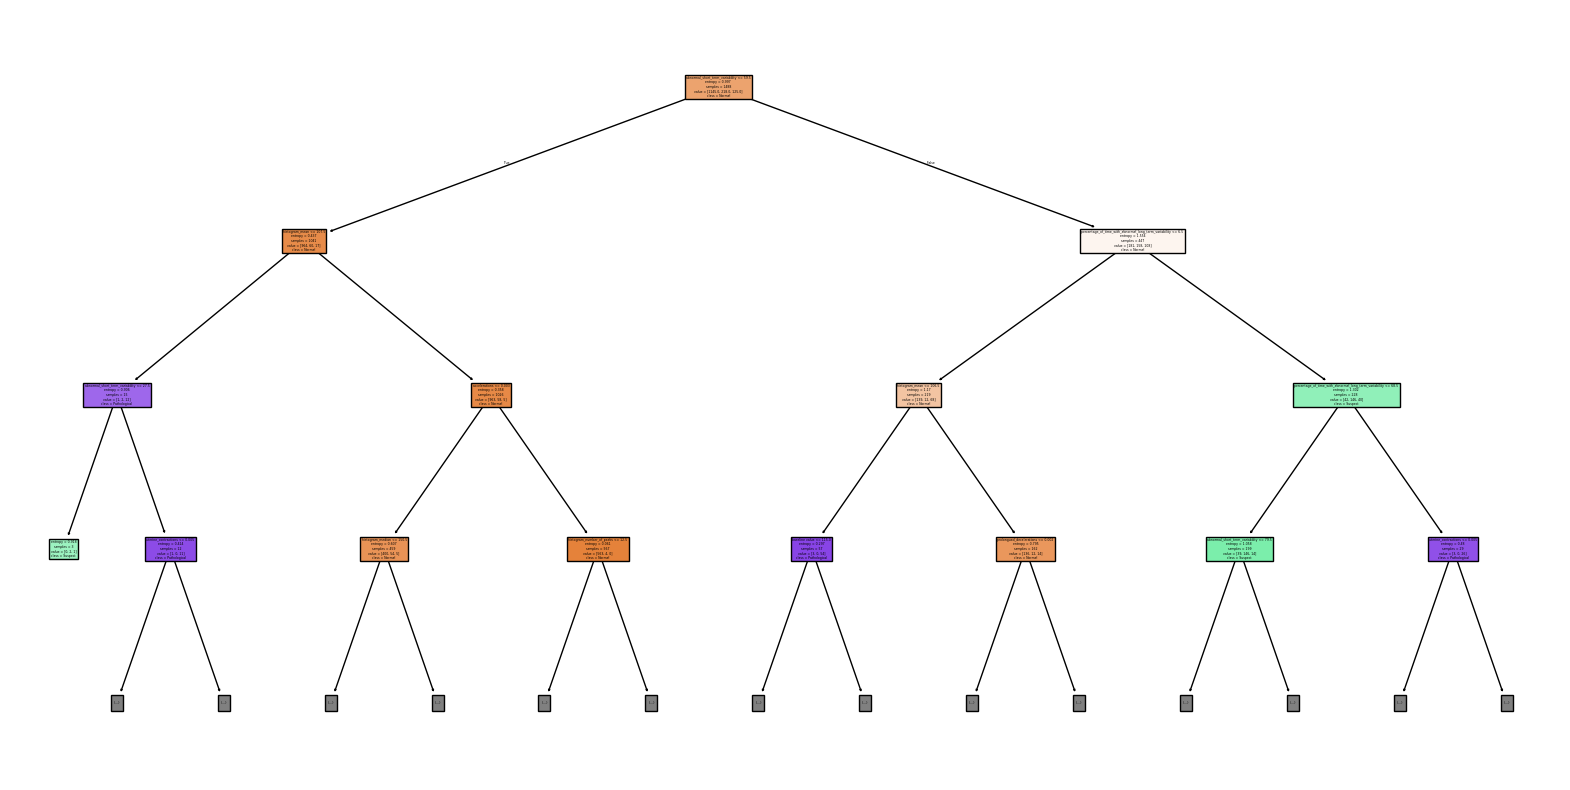

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=["Normal", "Suspect", "Pathological"],
    filled=True,
    max_depth=3
)

plt.show()